In [ ]:
from google.colab import files
uploaded=files.upload()

In [ ]:
import pandas as pd
df=pd.read_csv('tickets_english.csv')
df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
1,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
2,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN
3,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,en,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN
4,Problem with Integration,"The integration stopped working unexpectedly, ...",I will look into the problem and call you at <...,Problem,IT Support,high,en,Technical,Integration,Bug,Resolution,Outage,Documentation,NaN,NaN


In [ ]:
print(df.shape)
print(df['queue'].value_counts())
print(df[['subject','body']].isnull().sum())

(11923, 15)
queue
Technical Support                  3412
Product Support                    2232
Customer Service                   1859
IT Support                         1391
Billing and Payments               1302
Returns and Exchanges               582
Service Outages and Maintenance     442
Sales and Pre-Sales                 330
Human Resources                     205
General Inquiry                     168
Name: count, dtype: int64
subject    1032
body          1
dtype: int64


In [ ]:
df['subject']=df['subject'].fillna('')
df=df.dropna(subset=['body'])

df['text']= df['subject']+ ' ' + df['body']

print(df.shape)
print(df['text'].isnull().sum())

(11922, 16)
0


In [ ]:
df=df.copy()
df['subject']= df['subject'].fillna('')
df=df.dropna(subset=['body'])
df['text']=df['subject']+' '+df['body']

print(df.shape)
print(df['text'].isnull().sum())

(11922, 16)
0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(
    df['text'], df['queue'],
    test_size=0.2,
    random_state=42,
    stratify=df['queue']
)

print(x_train.shape, x_test.shape)

(9537,) (2385,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer=TfidfVectorizer(max_features=5000,stop_words='english')
x_train_tfidf=vectorizer.fit_transform(x_train)
x_test_tfidf=vectorizer.transform(x_test)

model=LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(x_train_tfidf,y_train)

print("Antrenare completa")

Antrenare completa


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred=model.predict(x_test_tfidf)

print(classification_report(y_test,y_pred))

                                 precision    recall  f1-score   support

           Billing and Payments       0.70      0.69      0.70       261
               Customer Service       0.31      0.25      0.28       372
                General Inquiry       0.10      0.35      0.16        34
                Human Resources       0.25      0.61      0.35        41
                     IT Support       0.32      0.36      0.34       278
                Product Support       0.42      0.25      0.31       446
          Returns and Exchanges       0.22      0.41      0.28       116
            Sales and Pre-Sales       0.12      0.36      0.18        66
Service Outages and Maintenance       0.35      0.64      0.45        88
              Technical Support       0.54      0.35      0.43       683

                       accuracy                           0.37      2385
                      macro avg       0.33      0.43      0.35      2385
                   weighted avg       0.43      0

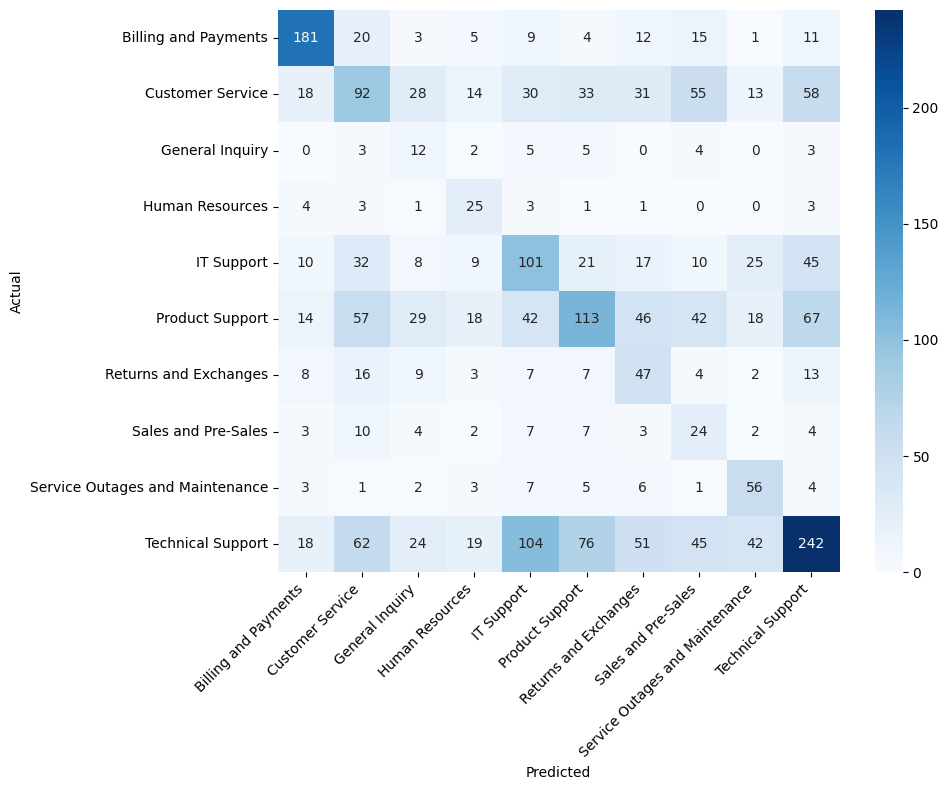

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(10,8))
cm=confusion_matrix(y_test,y_pred,labels=model.classes_)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=model.classes_,yticklabels=model.classes_,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

!pip install transformers datasets accelerate -q


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder=LabelEncoder()
df['label']=label_encoder.fit_transform(df['queue'])
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

{'Billing and Payments': 0, 'Customer Service': 1, 'General Inquiry': 2, 'Human Resources': 3, 'IT Support': 4, 'Product Support': 5, 'Returns and Exchanges': 6, 'Sales and Pre-Sales': 7, 'Service Outages and Maintenance': 8, 'Technical Support': 9}


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels= train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
print(len(train_texts), len(test_texts))

9537 2385


In [ ]:
from transformers import DistilBertTokenizer
tokenizer=DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings=tokenizer(train_texts,truncation=True,padding=True, max_length=256)
test_encodings=tokenizer(test_texts,truncation=True,padding=True,max_length=256)

print("Tokenizare completa")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizare completa


In [ ]:
import torch

class TicketDataset(torch.utils.data.Dataset):
  def __init__(self,encodings,labels):
    self.encodings=encodings
    self.labels=labels

  def __getitem__(self,idx):
    item={key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels']=torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

train_dataset=TicketDataset(train_encodings,train_labels)
test_dataset=TicketDataset(test_encodings,test_labels)

print(len(train_dataset), len(test_dataset))

9537 2385


In [ ]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
num_labels= len(label_encoder.classes_)

model_bert=DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

training_args=TrainingArguments(
    output_dir='/results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

trainer=Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,1.724618,1.615041
2,1.535810,1.556166
3,1.383101,1.532875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1791, training_loss=1.5051186378943329, metrics={'train_runtime': 684.9622, 'train_samples_per_second': 41.77, 'train_steps_per_second': 2.615, 'total_flos': 1895282730316800.0, 'train_loss': 1.5051186378943329, 'epoch': 3.0})

In [ ]:
import transformers
print(transformers.__version__)

5.16.1


In [ ]:
predictions= trainer.predict(test_dataset)
y_pred_bert=predictions.predictions.argmax(axis=1)

from sklearn.metrics import classification_report

print(classification_report(test_labels,y_pred_bert,target_names=label_encoder.classes_))

                                 precision    recall  f1-score   support

           Billing and Payments       0.78      0.70      0.74       261
               Customer Service       0.31      0.34      0.32       372
                General Inquiry       0.00      0.00      0.00        34
                Human Resources       0.82      0.34      0.48        41
                     IT Support       0.35      0.18      0.23       278
                Product Support       0.39      0.38      0.38       446
          Returns and Exchanges       0.48      0.12      0.19       116
            Sales and Pre-Sales       0.33      0.06      0.10        66
Service Outages and Maintenance       0.66      0.43      0.52        88
              Technical Support       0.46      0.70      0.55       683

                       accuracy                           0.45      2385
                      macro avg       0.46      0.32      0.35      2385
                   weighted avg       0.45      0

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

class_weights= compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights=torch.tensor(class_weights,dtype=torch.float).to(model_bert.device)

class WeightedTrainer(Trainer):
  def compute_loss(self,model,inputs,return_outputs=False,**kwargs):
    labels=inputs.pop("labels")
    outputs=model(**inputs)
    logits=outputs.logits
    loss_fct=nn.CrossEntropyLoss(weight=class_weights)
    loss=loss_fct(logits.view(-1,model.config.num_labels), labels.view(-1))
    return (loss,outputs) if return_outputs else loss

trainer=WeightedTrainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.483499,1.844826
2,1.067214,2.021671
3,0.760731,2.053599


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1791, training_loss=1.0350382861846124, metrics={'train_runtime': 724.1555, 'train_samples_per_second': 39.509, 'train_steps_per_second': 2.473, 'total_flos': 1895282730316800.0, 'train_loss': 1.0350382861846124, 'epoch': 3.0})

In [ ]:
predictions= trainer.predict(test_dataset)

y_pred_bert_weighted=predictions.predictions.argmax(axis=1)

print(classification_report(test_labels,y_pred_bert_weighted,target_names=label_encoder.classes_))

                                 precision    recall  f1-score   support

           Billing and Payments       0.64      0.74      0.69       261
               Customer Service       0.31      0.33      0.32       372
                General Inquiry       0.07      0.09      0.08        34
                Human Resources       0.56      0.37      0.44        41
                     IT Support       0.35      0.41      0.37       278
                Product Support       0.41      0.34      0.37       446
          Returns and Exchanges       0.19      0.33      0.24       116
            Sales and Pre-Sales       0.26      0.18      0.21        66
Service Outages and Maintenance       0.57      0.52      0.55        88
              Technical Support       0.51      0.45      0.48       683

                       accuracy                           0.42      2385
                      macro avg       0.39      0.37      0.37      2385
                   weighted avg       0.43      0

In [ ]:
trainer.save_model('./ticket-classifier-distilbert')
tokenizer.save_pretrained('./ticket-classifier-distilbert')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./ticket-classifier-distilbert/tokenizer_config.json',
 './ticket-classifier-distilbert/tokenizer.json')

In [ ]:
!pip install sentence-transformers faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 56.9 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer

embedder= SentenceTransformer('all-MiniLM-L6-v2')
print("Model de embeddings incarcat")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model de embeddings incarcat


In [ ]:
df_resolved = df.dropna(subset=['answer']).reset_index(drop=True)

ticket_embeddings=embedder.encode(df_resolved['text'].tolist(), show_progress_bar=True)

print(ticket_embeddings.shape)

Batches:   0%|          | 0/373 [00:00<?, ?it/s]

(11919, 384)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!pip install sentence-transformers faiss-cpu -q
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss

df_resolved=pd.read_csv('/content/drive/MyDrive/df_resolved.csv')

ticket_embeddings= np.load('/content/drive/MyDrive/ticket_embeddings.npy')

embeddings_np=ticket_embeddings.astype('float32')
dimension=embeddings_np.shape[1]
index=faiss.IndexFlatL2(dimension)
index.add(embeddings_np)

embedder=SentenceTransformer('all-MiniLM-L6-v2')

print("Totul incarcat din Drive, gata de lucru!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Totul incarcat din Drive, gata de lucru!


In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive'):
  print(f)

Colab Notebooks
ticket_embeddings.npy
df_resolved.csv


In [ ]:
query="My card was charged twice for the same order"

query_embedding= embedder.encode([query]).astype('float32')

k=5
distances, indices=index.search(query_embedding,k)

for i, idx in enumerate(indices[0]):
  print(f"--- Rezultat {i+1} (distanta: {distances[0][i]:.2f}) ---")
  print("Subject:", df_resolved.iloc[idx]['subject'])
  print("Queue:", df_resolved.iloc[idx]['queue'])
  print("Answer:", df_resolved.iloc[idx]['answer'][:150], "...")
  print()

--- Rezultat 1 (distanta: 0.77) ---
Subject: Double Charges on Recent Subscriptions - Issue Exist
Queue: Billing and Payments
Answer: Dear [Name], we apologize for the billing issues you are experiencing with double charges on recent subscriptions. We would like to assist in resolvin ...

--- Rezultat 2 (distanta: 0.77) ---
Subject: Resolving Unintended Duplicate Billing Problem
Queue: Billing and Payments
Answer: Hello <name>, we acknowledge your email concerning the unintended duplicate billing issue. We regret the inconvenience caused and are willing to help  ...

--- Rezultat 3 (distanta: 0.77) ---
Subject: Problem with Monthly Subscription Being Charged Twice
Queue: Billing and Payments
Answer: <name>, I'm sorry to hear that you were charged twice for the monthly subscription. We will investigate the matter and work on refunding the extra cha ...

--- Rezultat 4 (distanta: 0.80) ---
Subject: Problem with Monthly Subscription Double Charging
Queue: Billing and Payments
Answer: <nam

In [ ]:
def find_similar_tickets(query_text, k=5):
  query_embedding=embedder.encode([query_text]).astype('float32')
  distaces, indices=index.search(query_embedding, k)
  results= []
  for i,idx in enumerate(indices[0]):
    results.append({
        'subject': df_resolved.iloc[idx]['subject'],
        'queue': df_resolved.iloc[idx]['queue'],
        'answer': df_resolved.iloc[idx]['answer'],
        'distance': distances[0][i]
    })
  return results

In [5]:
def predict_category(text):
  inputs=tokenizer(text,truncation=True, padding=True, max_length=256, return_tensors='pt')
  inputs= {k: v.to(model_bert.device) for k, v in inputs.items()}

  with torch.no_grad():
    outputs= model_bert(**inputs)

  predicted_label=outputs.logits.argmax(dim=1).item()
  predicted_category= label_encoder.inverse_transform([predicted_label])[0]
  return predicted_category

In [6]:
def find_similar_tickets_filtered(query_text,k=5):
  predicted_category= predict_category(query_text)

  mask=df_resolved['queue']== predicted_category
  filtered_df= df_resolved[mask].reset_index(drop=True)
  filtered_embeddings=ticket_embeddings[mask.values].astype('float32')

  temp_index=faiss.IndexFlatL2(filtered_embeddings.shape[1])
  temp_index.add(filtered_embeddings)

  query_embedding=embedder.encode([query_text]).astype('float32')
  distances, indices=temp_index.search(query_embedding,min(k,len(filtered_df)))

  results= []
  for i, idx in enumerate(indices[0]):
    results.append({
        'subject': filtered_df.iloc[idx]['subject'],
        'queue': filtered_df.iloc[idx]['queue'],
        'answer': filtered_df.iloc[idx]['answer'],
        'distance': distances[0][i]
    })
  return predicted_category, results

In [ ]:
category, results= find_similar_tickets_filtered("My card was charged twice for the same order")
print("Categorie prezisa:", category)
print()
for i, r in enumerate(results):
  print(f"--- Rezultat {i+1} (distanta: {r['distance']:.2f}) ---")
  print("Subject:", r['subject'])
  print("Queue:", r['queue'])
  print("Answer:", r['answer'][:150], "...")
  print()

Categorie prezisa: Billing and Payments

--- Rezultat 1 (distanta: 0.77) ---
Subject: Double Charges on Recent Subscriptions - Issue Exist
Queue: Billing and Payments
Answer: Dear [Name], we apologize for the billing issues you are experiencing with double charges on recent subscriptions. We would like to assist in resolvin ...

--- Rezultat 2 (distanta: 0.77) ---
Subject: Resolving Unintended Duplicate Billing Problem
Queue: Billing and Payments
Answer: Hello <name>, we acknowledge your email concerning the unintended duplicate billing issue. We regret the inconvenience caused and are willing to help  ...

--- Rezultat 3 (distanta: 0.77) ---
Subject: Problem with Monthly Subscription Being Charged Twice
Queue: Billing and Payments
Answer: <name>, I'm sorry to hear that you were charged twice for the monthly subscription. We will investigate the matter and work on refunding the extra cha ...

--- Rezultat 4 (distanta: 0.80) ---
Subject: Problem with Monthly Subscription Double Charging

In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive'):
  print(f)

Colab Notebooks
ticket_embeddings.npy
df_resolved.csv


In [ ]:
trainer.save_model('/content/drive/MyDrive/ticket-classifier-distilbert')
tokenizer.save_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
print("Model salvat pe Drive!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model salvat pe Drive!


In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive/ticket-classifier-distilbert'):
  print(f)

config.json
model.safetensors
training_args.bin
tokenizer_config.json
tokenizer.json


In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
from sklearn.preprocessing import LabelEncoder

tokenizer= DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert=DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert.to('cuda' if torch.cuda.is_available() else 'cpu')

label_encoder = LabelEncoder()
label_encoder.fit(df_resolved['queue'])

print("Model DistilBERT incarcat din Drive")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model DistilBERT incarcat din Drive


In [ ]:
category, results= find_similar_tickets_filtered("My card was charged twice for the same order")
print("Categorie prezisa:", category)
print()
for i,r in enumerate(results):
  print(f"--- Resultat {i+1} (distanta: {r['distance']:.2f}) ---")
  print("Subject:", r['subject'])
  print("Queue:", r['queue'])
  print("Answer:", r['answer'][:150], "...")
  print()

Categorie prezisa: Billing and Payments

--- Resultat 1 (distanta: 0.77) ---
Subject: Double Charges on Recent Subscriptions - Issue Exist
Queue: Billing and Payments
Answer: Dear [Name], we apologize for the billing issues you are experiencing with double charges on recent subscriptions. We would like to assist in resolvin ...

--- Resultat 2 (distanta: 0.77) ---
Subject: Resolving Unintended Duplicate Billing Problem
Queue: Billing and Payments
Answer: Hello <name>, we acknowledge your email concerning the unintended duplicate billing issue. We regret the inconvenience caused and are willing to help  ...

--- Resultat 3 (distanta: 0.77) ---
Subject: Problem with Monthly Subscription Being Charged Twice
Queue: Billing and Payments
Answer: <name>, I'm sorry to hear that you were charged twice for the monthly subscription. We will investigate the matter and work on refunding the extra cha ...

--- Resultat 4 (distanta: 0.80) ---
Subject: Problem with Monthly Subscription Double Charging

In [ ]:
query_test= "I have a problem with my account"

query_embedding= embedder.encode([query_test]).astype('float32')
distances_all, indices_all= index.search(query_embedding, 5)

print("=== FARA filtrare (toate categoriile) ===")
for i, idx in enumerate(indices_all[0]):
  print(f"{i+1}. Queue: {df_resolved.iloc[idx]['queue']} (distanta: {distances_all[0][i]:.2f})")

print()

category, results= find_similar_tickets_filtered(query_test)
print(f"=== CU filtrare (categorie prezisa: {category}) ===")
for i, r in enumerate(results):
  print(f"{i+1}. Queue: {r['queue']} (distanta: {r['distance']:.2f})")

=== FARA filtrare (toate categoriile) ===
1. Queue: Billing and Payments (distanta: 0.69)
2. Queue: Customer Service (distanta: 0.70)
3. Queue: Customer Service (distanta: 0.78)
4. Queue: Billing and Payments (distanta: 0.80)
5. Queue: Billing and Payments (distanta: 0.83)

=== CU filtrare (categorie prezisa: Customer Service) ===
1. Queue: Customer Service (distanta: 0.70)
2. Queue: Customer Service (distanta: 0.78)
3. Queue: Customer Service (distanta: 0.94)
4. Queue: Customer Service (distanta: 0.94)
5. Queue: Customer Service (distanta: 0.94)


In [8]:
import torch.nn.functional as F

def predict_category_with_confidence(text):
  inputs= tokenizer(text,truncation=True, padding=True, max_length=256, return_tensors='pt')
  inputs={k: v.to(model_bert.device) for k, v in inputs.items()}

  with torch.no_grad():
    outputs= model_bert(**inputs)

  probs= F.softmax(outputs.logits,dim=1)
  confidence, predicted_label=torch.max(probs,dim=1)

  predicted_category= label_encoder.inverse_transform([predicted_label.item()])[0]
  return predicted_category, confidence.item()

In [9]:
def find_similar_tickets_hybrid(query_text, k=5, confidence_threshold=0.5):
  predicted_category, confidence= predict_category_with_confidence(query_text)
  query_embedding=embedder.encode([query_text]).astype('float32')

  if confidence >= confidence_threshold:
    mask=df_resolved['queue']== predicted_category
    filtered_df=df_resolved[mask].reset_index(drop=True)
    filtered_embeddings=ticket_embeddings[mask.values].astype('float32')

    temp_index= faiss.IndexFlatL2(filtered_embeddings.shape[1])
    temp_index.add(filtered_embeddings)

    distances, indices= temp_index.search(query_embedding, min(k, len(filtered_df)))
    source_df=filtered_df
    mode="filtrat"
  else:
    distances, indices=index.search(query_embedding,k)
    source_df=df_resolved
    mode="nefiltrat"

  results= []
  for i, idx in enumerate(indices[0]):
    results.append({
        'subject': source_df.iloc[idx]['subject'],
        'queue': source_df.iloc[idx]['queue'],
        'answer': source_df.iloc[idx]['answer'],
        'distance': distances[0][i]
    })
  return predicted_category, confidence, mode, results

In [ ]:
for query in ["My card was charged twice for the same order", "I have a problem with my account"]:
  category, confidence, mode, results= find_similar_tickets_hybrid(query,confidence_threshold=0.6)
  print(f"Query: {query}")
  print(f"Categorie prezisa: {category} | Incredere: {confidence:.2f} | Mod: {mode}")
  for i, r in enumerate(results):
    print(f" {i+1}. Queue: {r['queue']} (distanta: {r['distance']:.2f})")
  print()

Query: My card was charged twice for the same order
Categorie prezisa: Billing and Payments | Incredere: 1.00 | Mod: filtrat
 1. Queue: Billing and Payments (distanta: 0.77)
 2. Queue: Billing and Payments (distanta: 0.77)
 3. Queue: Billing and Payments (distanta: 0.77)
 4. Queue: Billing and Payments (distanta: 0.80)
 5. Queue: Billing and Payments (distanta: 0.80)

Query: I have a problem with my account
Categorie prezisa: Customer Service | Incredere: 0.52 | Mod: nefiltrat
 1. Queue: Billing and Payments (distanta: 0.69)
 2. Queue: Customer Service (distanta: 0.70)
 3. Queue: Customer Service (distanta: 0.78)
 4. Queue: Billing and Payments (distanta: 0.80)
 5. Queue: Billing and Payments (distanta: 0.83)



In [ ]:
!pip install anthropic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.6 MB/s eta 0:00:00


In [13]:
!pip install google-generativeai -q

In [14]:
from google.colab import userdata
import google.generativeai as genai

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
model_gemini=genai.GenerativeModel('gemini-2.0-flash')

print("Client Gemini configurat")

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Client Gemini configurat


In [15]:
!pip install google-genai -q

In [16]:
from google.colab import userdata
from google import genai

client_gemini= genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

print("Client Gemini configurat")

Client Gemini configurat


In [11]:
def generate_response(ticket_text, similar_results):
  context=""
  for i, r in enumerate(similar_results):
    context+=f"\nExemplu {i+1}: \nTicket similar: {r['subject']}\nSolutie folosita: {r['answer']}\n"
  prompt= f"""Esti un asistent de suport clienti. Ai primit un ticket nou de la un client:

"{ticket_text}"

Iata cateva cazuri similare rezolvate anterior, care te pot ajuta sa formulezi un raspuns:
{context}

Scrie un raspuns profesional si empatic pentru ticketul nou, inspirat din exemplele de mai sus, dar adaptat specific la acest caz."""
  response=client_gemini.models.generate_content(
      model='gemini-3.5-flash-lite',
      contents=prompt
  )
  return response.text

In [ ]:
for m in client_gemini.models.list():
  print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

In [ ]:
ticket_nou= "My card was charged twice for the same order"

category, confidence, mode, results = find_similar_tickets_hybrid(ticket_nou)
raspuns_generat=generate_response(ticket_nou,results)

print("Categorie:", category)
print("Incredere:", confidence)
print("\nRaspuns generat:\n")
print(raspuns_generat)

Categorie: Billing and Payments
Incredere: 0.9953805208206177

Raspuns generat:

Salut! Iată un Răspuns profesional și empatic, inspirat din exemplele anterioare, pe care îl poți trimite clientului:

***

**Subiect:** Re: Problemă facturare - Dublă taxare pentru aceeași comandă

Dragă [Name],

Îmi pare rău să aud că ați fost taxat(ă) de două ori pentru aceeași comandă. Înțeleg pe deplin neplăcerea creată și dorim să vă asigurăm că vom investiga această situație și vom lucra la rambursarea sumei percepute în plus cât mai curând posibil.

Pentru a ne ajuta în procesul de investigare și soluționare rapidă, ați putea, vă rog, să ne furnizați numărul dumneavoastră de cont ([Acc Num]), data tranzacției și suma exactă a taxării duble? 

Vă rugăm să ne acordați 24-48 de ore pentru a verifica problema în sistemul nostru. Vă vom ține la curent cu stadiul rambursării și cu pașii suplimentari necesari. Dacă este nevoie să discutăm mai detaliat, ne puteți contacta la numărul de telefon [Tel Number]

In [1]:
!pip install sentence-transformers faiss-cpu -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
from sklearn.preprocessing import LabelEncoder

df_resolved= pd.read_csv('/content/drive/MyDrive/df_resolved.csv')
ticket_embeddings= np.load('/content/drive/MyDrive/ticket_embeddings.npy')

embeddings_np= ticket_embeddings.astype('float32')
dimension=embeddings_np.shape[1]
index=faiss.IndexFlatL2(dimension)
index.add(embeddings_np)

embedder=SentenceTransformer('all-MiniLM-L6-v2')

tokenizer=DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert=DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert.to('cuda' if torch.cuda.is_available() else 'cpu')

label_encoder=LabelEncoder()
label_encoder.fit(df_resolved['queue'])

print("Totul incarcat din Drive, gata de lucru!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 58.6 MB/s eta 0:00:00
Mounted at /content/drive


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Totul incarcat din Drive, gata de lucru!


In [3]:
import time
def generate_response_with_retry(ticket_text, similar_results, max_retries=6):
  for attempt in range(max_retries):
    try:
      return generate_response(ticket_text,similar_results)
    except Exception as e:
      print(f"Incercare {attempt+1}/{max_retries} esuata: {e}")
      if attempt< max_retries -1:
        wait_time= 15* (attempt+1)
        print(f"Astept {wait_time} secunde...")
        time.sleep(wait_time)
    return None

In [2]:
def process_ticket(ticket_text):
  category, confidence, mode, results=find_similar_tickets_hybrid(ticket_text)
  response= generate_response_with_retry(ticket_text,results)
  return {
      'category': category,
      'confidence': confidence,
      'mode': mode,
      'generated_response': response
  }

In [17]:
test_tickets= [
    "My card was charged twice for the same order",
    "The product I received is defective and I want a refund",
    "I'm having trouble logging into my account",
    "I have a problem with my account"
]

for ticket in test_tickets:
  print("=" * 60)
  print(f"TICKET: {ticket}")
  print("="*60)
  result=process_ticket(ticket)
  print(f"Categorie: {result['category']} | Incredere: {result['confidence']:.2f} | Mod: {result['mode']}")
  print(f"\nRaspuns generat:\n{result['generated_response']}")
  print()

TICKET: My card was charged twice for the same order
Categorie: Billing and Payments | Incredere: 1.00 | Mod: filtrat

Raspuns generat:
Salut! Iată un răspuns profesional și empatic, inspirat din exemplele de mai sus și adaptat pentru situația clientului:

***

Dear [Name],

I'm very sorry to hear that your card was charged twice for the same order. We completely understand how frustrating this can be, and we want to assure you that we are here to help resolve this matter as quickly as possible.

We will investigate this issue right away and work on processing a refund for the extra charge. To assist us with the investigation, could you please provide your account number [Account Number] and confirm the exact date and amount of the duplicate charge? 

Please allow us 24-48 hours to look into this, and we will update you regarding the refund and any additional steps needed. If you would prefer to discuss this further over the phone, please let us know your preferred phone number and a c